In [1]:
import joblib

model = joblib.load(
    "cleaned_data/traffic_prediction_model.pkl"
)

features = joblib.load(
    "cleaned_data/model_features.pkl"
)

print("Model:", type(model).__name__)
print("Number of features:", len(features))
print("Features:")
print(features)

Model: XGBClassifier
Number of features: 20
Features:
['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [2]:
def predict_traffic(features):
    
    model = joblib.load(
        "cleaned_data/traffic_prediction_model.pkl"
    )

    prediction = model.predict(features)

    return prediction

In [3]:
import pandas as pd

# Load the cleaned mobility dataset
df = pd.read_csv("cleaned_data/mobility_cleaned.csv")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (5000, 15)
Columns:
['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Traffic_Condition']


In [4]:
print("Features expected by model:")
print(features)

print("\nColumns in current dataset:")
print(df.columns.tolist())

Features expected by model:
['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']

Columns in current dataset:
['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Traffic_Condition']


In [5]:
missing_features = [
    feature for feature in features
    if feature not in df.columns
]

print("Missing features:")
print(missing_features)

Missing features:
['Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [6]:
extra_columns = [
    column for column in df.columns
    if column not in features
]

print("Extra columns:")
print(extra_columns)

Extra columns:
['Timestamp', 'Traffic_Light_State', 'Weather_Condition', 'Traffic_Condition']


In [7]:
print(features)

['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [8]:
print(df.columns.tolist())

['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Traffic_Condition']


In [9]:
missing_features = [
    feature for feature in features
    if feature not in df.columns
]

print(missing_features)

['Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [10]:
# Make a copy so the original dataset is not changed
integration_df = df.copy()

# -------------------------
# 1. Convert Timestamp
# -------------------------
integration_df["Timestamp"] = pd.to_datetime(
    integration_df["Timestamp"],
    errors="coerce"
)

# -------------------------
# 2. Create time features
# -------------------------
integration_df["Hour"] = integration_df["Timestamp"].dt.hour
integration_df["Day"] = integration_df["Timestamp"].dt.day
integration_df["Month"] = integration_df["Timestamp"].dt.month
integration_df["DayOfWeek"] = integration_df["Timestamp"].dt.dayofweek

# -------------------------
# 3. One-hot encode
# -------------------------
integration_df = pd.get_dummies(
    integration_df,
    columns=[
        "Traffic_Light_State",
        "Weather_Condition"
    ],
    dtype=int
)

print(integration_df.columns.tolist())

['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Traffic_Condition', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Green', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Clear', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [11]:
integration_df = integration_df.drop(
    columns=["Timestamp", "Traffic_Condition"],
    errors="ignore"
)

In [12]:
X_integration = integration_df.reindex(
    columns=features,
    fill_value=0
)

print("Integration feature shape:", X_integration.shape)
print("Expected feature count:", len(features))

Integration feature shape: (5000, 20)
Expected feature count: 20


In [13]:
print(X_integration.columns.tolist())

['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Traffic_Light_State_Red', 'Traffic_Light_State_Yellow', 'Weather_Condition_Fog', 'Weather_Condition_Rain', 'Weather_Condition_Snow']


In [14]:
X_sample = X_integration.iloc[[0]]

prediction = model.predict(X_sample)

print("Predicted Traffic Condition:", prediction)

Predicted Traffic Condition: [0]


In [15]:
actual = df["Traffic_Condition"].iloc[0]

print("Actual Traffic Condition   :", actual)
print("Predicted Traffic Condition:", prediction[0])

Actual Traffic Condition   : High
Predicted Traffic Condition: 0


In [16]:
X_test_integration = X_integration.iloc[:10]

predictions = model.predict(X_test_integration)

print("Predictions:")
print(predictions)

Predictions:
[0 0 0 0 1 0 0 2 0 1]


In [17]:
print("Actual:")
print(df["Traffic_Condition"].iloc[:10].values)

Actual:
<StringArray>
['High', 'High', 'High', 'High', 'Low', 'High', 'High', 'Medium', 'High',
 'Low']
Length: 10, dtype: str


In [18]:
label_encoder = joblib.load(
    "cleaned_data/label_encoder.pkl"
)

print("Classes:", label_encoder.classes_)

Classes: ['High' 'Low' 'Medium']


In [19]:
predicted_labels = label_encoder.inverse_transform(
    predictions.astype(int)
)

print("Predicted:")
print(predicted_labels)

Predicted:
['High' 'High' 'High' 'High' 'Low' 'High' 'High' 'Medium' 'High' 'Low']


In [20]:
actual_labels = df["Traffic_Condition"].iloc[:10].values

comparison = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

comparison

,Actual,Predicted
0,High,High
1,High,High
2,High,High
3,High,High
4,Low,Low
5,High,High
6,High,High
7,Medium,Medium
8,High,High
9,Low,Low


In [21]:
from sklearn.metrics import accuracy_score

In [22]:
integration_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

print("Integration Test Accuracy:", integration_accuracy)

Integration Test Accuracy: 1.0


In [23]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Actual labels
actual_labels = df["Traffic_Condition"].iloc[:10].values

# Convert encoded predictions back to labels
predicted_labels = label_encoder.inverse_transform(
    predictions.astype(int)
)

# Display comparison
comparison = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

print("Prediction Comparison:")
display(comparison)

# Calculate accuracy
integration_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

print("\nIntegration Test Accuracy:", integration_accuracy)

Prediction Comparison:


,Actual,Predicted
0,High,High
1,High,High
2,High,High
3,High,High
4,Low,Low
5,High,High
6,High,High
7,Medium,Medium
8,High,High
9,Low,Low



Integration Test Accuracy: 1.0


In [24]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\DELL\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [25]:
model_yolo = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully")

YOLOv8 model loaded successfully


In [36]:
results = model_yolo("traffic.png")

print("Detection completed")

Detection completed


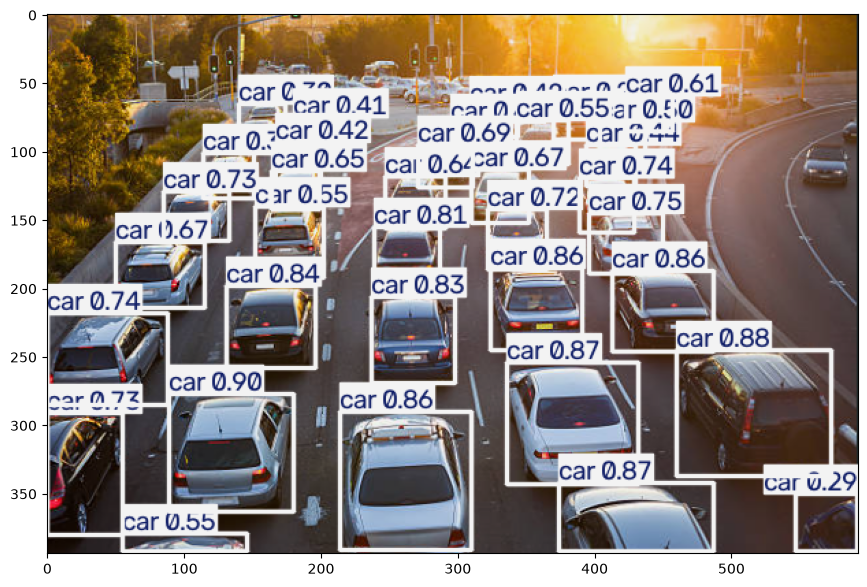

In [28]:
annotated_image = results[0].plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("on")
plt.show()

In [29]:
vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}

vehicle_counts = {
    "car": 0,
    "motorcycle": 0,
    "bus": 0,
    "truck": 0
}

for box in results[0].boxes:
    class_id = int(box.cls[0])

    if class_id in vehicle_classes:
        vehicle_name = vehicle_classes[class_id]
        vehicle_counts[vehicle_name] += 1

print("Vehicle Counts:")
print(vehicle_counts)

total_vehicles = sum(vehicle_counts.values())

print("Total Vehicles:", total_vehicles)

Vehicle Counts:
{'car': 35, 'motorcycle': 0, 'bus': 0, 'truck': 0}
Total Vehicles: 35


In [30]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    if class_id in vehicle_classes:
        print(
            vehicle_classes[class_id],
            "Confidence:",
            round(confidence, 2)
        )

car Confidence: 0.9
car Confidence: 0.88
car Confidence: 0.87
car Confidence: 0.87
car Confidence: 0.86
car Confidence: 0.86
car Confidence: 0.86
car Confidence: 0.84
car Confidence: 0.83
car Confidence: 0.81
car Confidence: 0.75
car Confidence: 0.74
car Confidence: 0.74
car Confidence: 0.73
car Confidence: 0.73
car Confidence: 0.72
car Confidence: 0.69
car Confidence: 0.67
car Confidence: 0.67
car Confidence: 0.65
car Confidence: 0.64
car Confidence: 0.61
car Confidence: 0.55
car Confidence: 0.55
car Confidence: 0.55
car Confidence: 0.5
car Confidence: 0.44
car Confidence: 0.43
car Confidence: 0.42
car Confidence: 0.42
car Confidence: 0.41
car Confidence: 0.36
car Confidence: 0.3
car Confidence: 0.29
car Confidence: 0.26


In [31]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Could not open webcam")
else:
    print("Webcam opened successfully")

Webcam opened successfully


In [33]:
cap = cv2.VideoCapture(0)

vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model_yolo(frame, verbose=False)

    counts = {
        "car": 0,
        "motorcycle": 0,
        "bus": 0,
        "truck": 0
    }

    for box in results[0].boxes:

        class_id = int(box.cls[0])

        if class_id in vehicle_classes:

            vehicle_name = vehicle_classes[class_id]

            counts[vehicle_name] += 1

    total_vehicles = sum(counts.values())

    annotated_frame = results[0].plot()

    cv2.putText(
        annotated_frame,
        f"Vehicles: {total_vehicles}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow(
        "Smart Traffic - YOLOv8",
        annotated_frame
    )

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()